# 07 Stylometric_Feature_Clustering.ipynb  
### Unsupervised Clustering of Stylometric Features  
**Pipeline A — Global Structure Analysis**

This notebook applies unsupervised learning to the stylometric features extracted in Pipeline A.  
It helps answer:  

**Do AI and Human texts naturally separate in stylometric feature space?**

Performing:

- Feature scaling (StandardScaler)  
- Dimensionality reduction (PCA)  
- Clustering (KMeans)  
- Cluster purity analysis  
- Cluster‐level feature summaries  
- PCA visualization  
- Heatmaps of cluster centers  

This complements interpretability by revealing how writing style groups globally.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import mode

sns.set(style="whitegrid")


In [3]:
file_path = r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_Features.xlsx"

df = pd.read_excel(file_path)
df.head()


,Text,Label,char_count,word_count,sentence_count,paragraph_count,punctuation_count,avg_word_length,avg_sentence_length,unique_word_count,...,sentiment_subjectivity,ppl_mean,ppl_max,discourse_marker_count,title_repetition_count,title_repetition_ratio,word_entropy,char_entropy,avg_sentence_similarity,std_sentence_similarity
0,6 top keywords used in the meta keywords tags ...,0,82,16,1,1,1,5.125000,16.000000,12,...,0.500000,108.407303,108.407303,0,0,0.0,3.500000,3.931515,0.407276,0.121442
1,The officer leading the police investigation i...,0,179,26,1,1,4,6.884615,26.000000,24,...,0.666667,36.297779,36.297779,0,0,0.0,4.546594,4.256504,0.407276,0.121442
2,It 's biology vs you . Our ancestors were prog...,0,394,82,7,1,15,4.804878,11.714286,58,...,0.562698,534.182751,1752.759888,0,0,0.0,5.626867,4.308066,0.320988,0.142229
3,Short version : Lazy programmers . Long versio...,0,320,64,2,1,6,5.000000,32.000000,43,...,0.477778,521.213543,1412.020752,0,0,0.0,5.188810,4.146873,0.305164,0.168947
4,But after the formation of infertility jumbled...,0,64,10,1,1,2,6.400000,10.000000,10,...,0.000000,573.732788,573.732788,0,0,0.0,3.321928,4.114558,0.407276,0.121442


In [4]:
print("Columns:", df.columns.tolist())
print(df.shape)


Columns: ['Text', 'Label', 'char_count', 'word_count', 'sentence_count', 'paragraph_count', 'punctuation_count', 'avg_word_length', 'avg_sentence_length', 'unique_word_count', 'unique_word_ratio', 'hapax_legomena_ratio', 'stopword_count', 'stopword_ratio', 'special_char_count', 'uppercase_ratio', 'digit_ratio', 'flesch_reading_ease', 'flesch_kincaid_grade', 'automated_readability_index', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 'personal_pronoun_count', 'personal_pronoun_ratio', 'pos_per_sentence_mean', 'sentiment_polarity', 'sentiment_subjectivity', 'ppl_mean', 'ppl_max', 'discourse_marker_count', 'title_repetition_count', 'title_repetition_ratio', 'word_entropy', 'char_entropy', 'avg_sentence_similarity', 'std_sentence_similarity']
(10000, 38)


In [5]:
feature_cols = [c for c in df.columns if c.lower() not in ["label", "text"]]

X = df[feature_cols]
y = df["Label"].values

print("Feature matrix shape:", X.shape)


Feature matrix shape: (10000, 36)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.27381574 0.12545462]


In [8]:
# K-Means

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster_labels


In [9]:
sil = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score: {sil:.4f}")


Silhouette Score: 0.2025


In [10]:
def cluster_purity(cluster_labels, true_labels):
    clusters = np.unique(cluster_labels)
    purities = []

    for c in clusters:
        idx = np.where(cluster_labels == c)[0]
        majority = mode(true_labels[idx], keepdims=True).mode[0]
        purity = (true_labels[idx] == majority).mean()
        purities.append(purity)

    return np.mean(purities)

purity = cluster_purity(cluster_labels, y)
print(f"Cluster Purity: {purity:.4f}")


Cluster Purity: 0.5380


#### PCA Plot Colored By Cluster

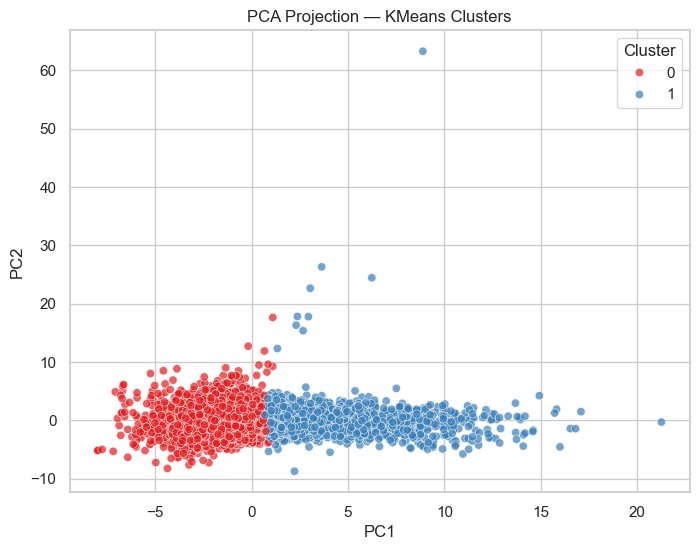

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1],
    hue=df["Cluster"],
    palette="Set1",
    alpha=0.7
)
plt.title("PCA Projection — KMeans Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


#### PCA Plot Colored By True Label

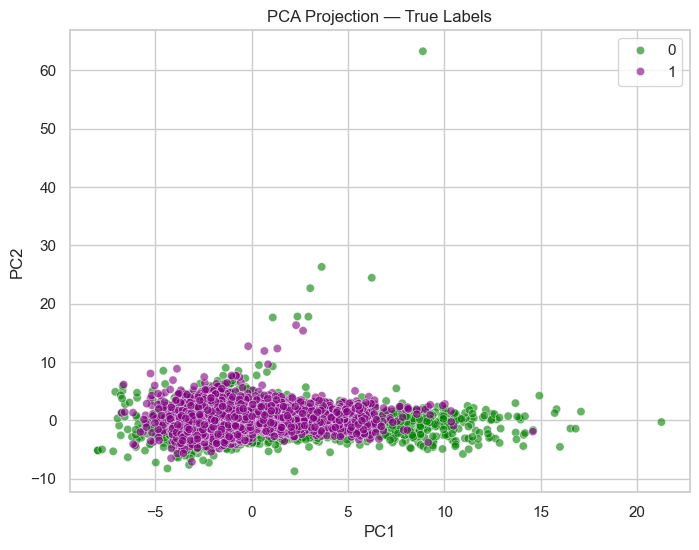

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1],
    hue=y,
    palette={0:"green", 1:"purple"},
    alpha=0.6
)
plt.title("PCA Projection — True Labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [14]:
# Cluster Center Feature Summary:

cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)

cluster_centers


,char_count,word_count,sentence_count,paragraph_count,punctuation_count,avg_word_length,avg_sentence_length,unique_word_count,unique_word_ratio,hapax_legomena_ratio,...,sentiment_subjectivity,ppl_mean,ppl_max,discourse_marker_count,title_repetition_count,title_repetition_ratio,word_entropy,char_entropy,avg_sentence_similarity,std_sentence_similarity
0,-0.552166,-0.548906,-0.531701,-0.34427,-0.508456,0.035321,-0.037833,-0.564018,0.583421,0.550388,...,-0.192430,0.032890,-0.009915,-0.310207,-0.036615,0.000244,-0.518571,-0.172989,-0.197004,-0.232507
1,1.035431,1.029317,0.997054,0.64558,0.953465,-0.066234,0.070945,1.057656,-1.094039,-1.032096,...,0.360849,-0.061677,0.018593,0.581704,0.068661,-0.000457,0.972433,0.324392,0.369425,0.436002


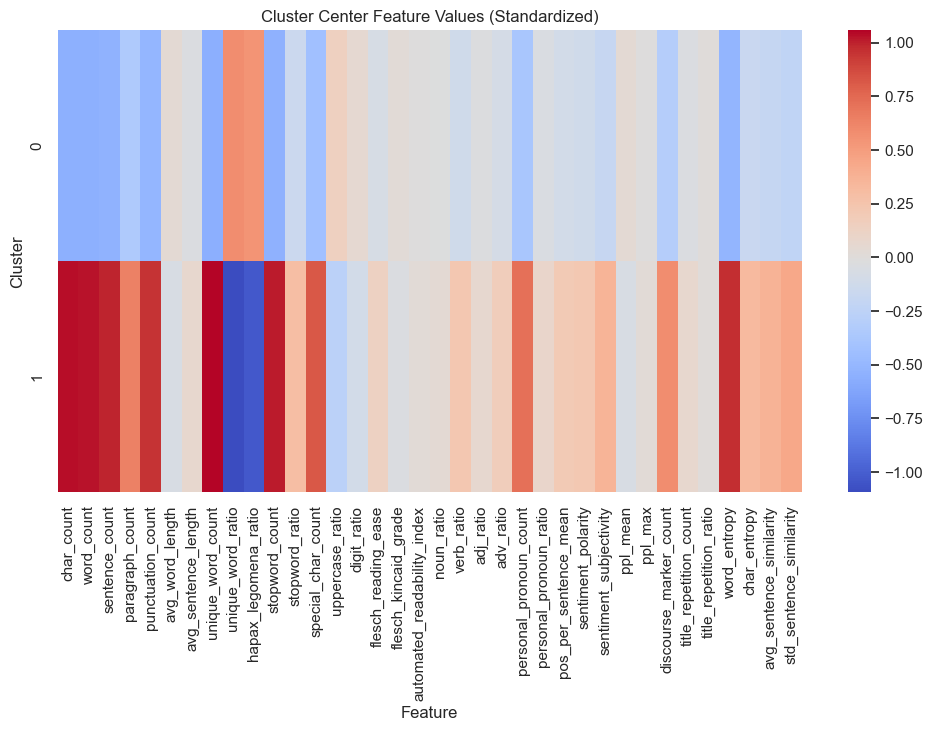

In [15]:
# Heatmap of Cluster Centers:

plt.figure(figsize=(12,6))
sns.heatmap(cluster_centers, cmap="coolwarm", annot=False)
plt.title("Cluster Center Feature Values (Standardized)")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.show()


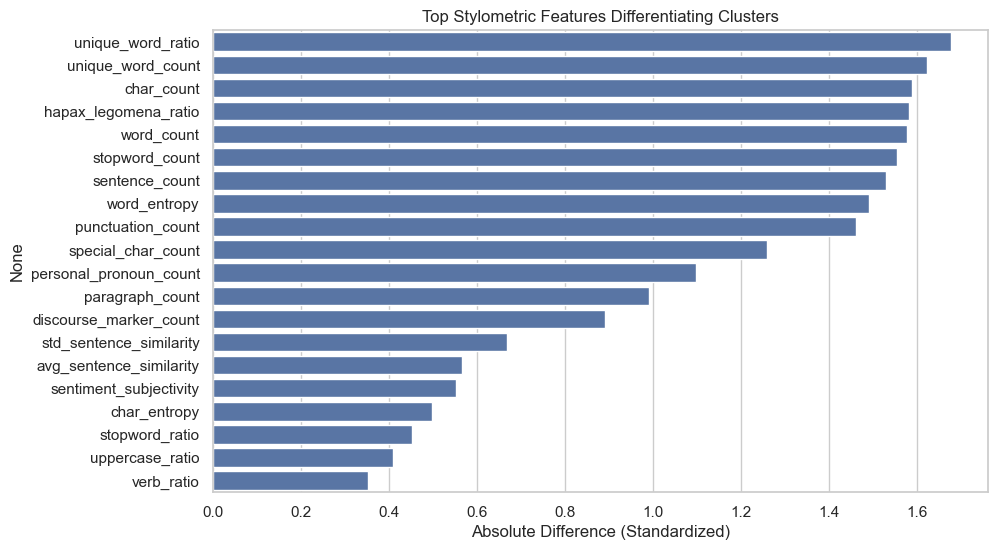

In [16]:
diff = (cluster_centers.iloc[0] - cluster_centers.iloc[1]).abs()
top_features = diff.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top Stylometric Features Differentiating Clusters")
plt.xlabel("Absolute Difference (Standardized)")
plt.show()


In [17]:
summary_df = pd.DataFrame({
    "Metric": ["Silhouette Score", "Cluster Purity"],
    "Value": [sil, purity]
})

summary_df


,Metric,Value
0,Silhouette Score,0.202548
1,Cluster Purity,0.538028


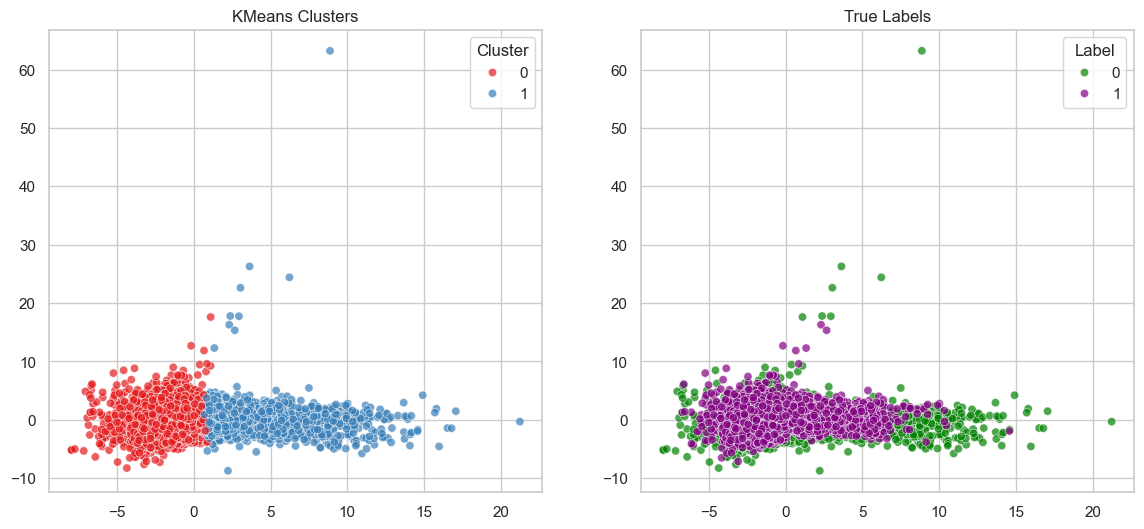

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1], hue=df["Cluster"],
    palette="Set1", alpha=0.7, ax=ax[0]
)
ax[0].set_title("KMeans Clusters")

sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1], hue=df["Label"],
    palette={0:"green", 1:"purple"}, alpha=0.7, ax=ax[1]
)
ax[1].set_title("True Labels")

plt.show()


In [20]:
import textwrap

for cl in sorted(df["Cluster"].unique()):
    print("\n" + "="*60)
    print(f"                 CLUSTER {cl}")
    print("="*60)

    sample_texts = df[df["Cluster"] == cl].sample(3, random_state=42)["Text"].tolist()

    for i, t in enumerate(sample_texts, 1):
        print(f"\n--- Sample {i} ---")
        print(textwrap.fill(t, width=110))   # nicely wrapped
        print("\n" + "-"*60)



                 CLUSTER 0

--- Sample 1 ---
County Armagh in Northern Ireland is enjoying a bumper apple harvest, despite a frost in May that destroyed
much of the blossom. Many producers lost half their crop, however, others managed to recover up to 90%.
Although a precarious business, about 250 commercial growers in the area are in the middle of a current six-
week window to bring in their harvest of Bramley apples,Â and to a lesser extent, eating varieties. Edmund
Allan,Â who farms 70 acres of orchard on Grange Lodge farm outside Loughgall,Â said the climate, soil and
3,000 years of apple-growing experience helped Armagh's apple farms.

------------------------------------------------------------

--- Sample 2 ---
Currently, despite a high male birth rate, Albania is facing a decline in overall birth rate, although
compared to other countries in the region, it still ranks first.

------------------------------------------------------------

--- Sample 3 ---
["Foamy feces in a pneu

In [21]:
df.to_excel(r"C:\Users\ajha26\Desktop\IS\Results\Stylometric_Clusters_Assigned.xlsx", index=False)

cluster_centers.to_excel(r"C:\Users\ajha26\Desktop\IS\Results\Stylometric_Cluster_Centers.xlsx")
